# EDA — Big Picture to Small

Exploratory analysis over the Silver layer (`fact_events` + `dim_ad` + `dim_user`), moving from
overall volume down to category/brand/customer breakdowns and feature correlations.

| Section | Question |
|---|---|
| 1. Overview | How many records, what date range, what's the overall CTR? |
| 2. By day | Does volume or CTR shift day to day? |
| 3. By category | Which categories carry the most traffic, and which convert best? |
| 4. By brand | Same, at brand granularity |
| 5. Correlations | Which numeric features actually relate to click (target), and which move together with each other (multicollinearity)? |
| 6. Customer overview | How many users, how active are they, how concentrated is engagement? |
| 7. Customer segments | Does population size or CTR differ by gender/age/shopping level/occupation/value tier? |
| 8. Engagement distribution | Is activity long-tailed — do a few users dominate impressions/clicks? |
| 9. Ad performance features | How do `ag_clicks_before`/`ag_ctr_before`/`ag_ctr_last_1d`/`_3d` behave across ads — exposure vs. conversion, and which ads are trending up or down? |

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots

SILVER_DIR = Path("../data/silver")
GOLD_DIR = Path("../data/gold")

parts = sorted((SILVER_DIR / "fact_events").glob("dt=*/part.parquet"))
fact = pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
dim_ad = pd.read_parquet(SILVER_DIR / "dim_ad.parquet")
dim_user = pd.read_parquet(SILVER_DIR / "dim_user.parquet")

df = fact.merge(dim_ad, on="adgroup_id", how="left").merge(dim_user, on="userid", how="left")
df["date"] = pd.to_datetime(df["date"])
df.shape

(300000, 22)

In [58]:
df

,userid,adgroup_id,time_stamp,click,pid,hour,weekday,date,_split,cate_id,...,brand,price,cms_segid,cms_group_id,final_gender_code,age_level,pvalue_level,shopping_level,occupation,new_user_class_level
0,170212,591197,2017-05-05 16:00:03,0,430539_1007,16,4,2017-05-05,train,4282,...,454237,439.00,0,4,2,4,unknown,3,0,4
1,393094,632232,2017-05-05 16:00:03,0,430539_1007,16,4,2017-05-05,train,4281,...,82527,98.00,44,5,2,5,2,3,0,2
2,244280,664671,2017-05-05 16:00:04,0,430548_1007,16,4,2017-05-05,train,6261,...,unknown,136.25,0,9,1,3,unknown,3,0,2
3,851217,578422,2017-05-05 16:00:04,0,430548_1007,16,4,2017-05-05,train,6261,...,224164,328.00,0,4,2,4,unknown,3,0,2
4,756736,725105,2017-05-05 16:00:05,0,430548_1007,16,4,2017-05-05,train,4284,...,82527,118.00,0,4,2,4,unknown,3,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,727985,582235,2017-05-13 15:59:06,1,430548_1007,15,5,2017-05-13,test,4283,...,unknown,99.00,0,5,2,5,unknown,2,0,3
299996,473295,673760,2017-05-13 15:59:06,0,430548_1007,15,5,2017-05-13,test,4282,...,unknown,69.90,0,3,2,3,unknown,3,0,2
299997,1118097,649815,2017-05-13 15:59:09,0,430539_1007,15,5,2017-05-13,test,1665,...,unknown,286.00,0,4,2,4,unknown,3,0,4
299998,960999,736041,2017-05-13 15:59:20,0,430539_1007,15,5,2017-05-13,test,6261,...,unknown,588.00,19,3,2,3,2,3,0,2


In [64]:
check_user = df.groupby(['userid'])['adgroup_id'].nunique().reset_index().rename(columns={'adgroup_id':'n_adgroups'})
check_user['n_adgroups'].value_counts(normalize = True).round(4)

# print(df['userid'].nunique())

n_adgroups
1     0.6773
2     0.1871
3     0.0672
4     0.0291
5     0.0143
6     0.0084
7     0.0048
8     0.0032
9     0.0025
10    0.0016
11    0.0011
12    0.0010
13    0.0007
14    0.0004
15    0.0003
16    0.0002
17    0.0002
18    0.0001
19    0.0001
20    0.0001
22    0.0001
23    0.0001
21    0.0000
24    0.0000
26    0.0000
25    0.0000
27    0.0000
41    0.0000
28    0.0000
34    0.0000
Name: proportion, dtype: float64

## 1. Big picture

In [2]:
overview = pd.DataFrame({
    "value": [
        len(df),
        df["date"].min().date(),
        df["date"].max().date(),
        df["date"].nunique(),
        df["userid"].nunique(),
        df["adgroup_id"].nunique(),
        int((df["_split"] == "train").sum()),
        int((df["_split"] == "test").sum()),
        f"{df['click'].mean():.4%}",
    ],
}, index=[
    "total impressions", "start date", "end date", "days",
    "unique users", "unique ads", "train rows", "test rows", "overall CTR",
])
overview

,value
total impressions,300000
start date,2017-05-05
end date,2017-05-13
days,9
unique users,174283
unique ads,300
train rows,240000
test rows,60000
overall CTR,20.0000%


## 2. Volume & CTR by day

In [3]:
by_day = (
    df.groupby("date")
    .agg(
        impressions=("click", "size"),
        ctr=("click", "mean")
    )
    .reset_index()
)

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Impressions (bars)
fig.add_trace(
    go.Bar(
        x=by_day["date"],
        y=by_day["impressions"],
        name="Impressions",
        opacity=0.8,
    ),
    secondary_y=False,
)

# CTR (line with % labels)
fig.add_trace(
    go.Scatter(
        x=by_day["date"],
        y=by_day["ctr"],
        mode="lines+markers+text",
        name="CTR",
        text=[f"{x:.1%}" for x in by_day["ctr"]],
        textposition="top center",
        hovertemplate="<b>%{x}</b><br>CTR: %{y:.2%}<extra></extra>",
    ),
    secondary_y=True,
)

fig.update_layout(
    title="Impressions (bars) & CTR (line) by day",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1,
    ),
)

fig.update_yaxes(
    title_text="Impressions",
    secondary_y=False,
)

fig.update_yaxes(
    title_text="CTR",
    tickformat=".0%",
    range=[0.15, 0.25],      # 15%–25%
    secondary_y=True,
)

fig.update_xaxes(
    tickformat="%Y-%m-%d",
    tickangle=-45,
)

fig.show()

## 3. Volume & CTR by category

In [23]:
# Aggregate
by_cate = (
    df.groupby("cate_id")
    .agg(
        impressions=("click", "size"),
        ctr=("click", "mean")
    )
    .sort_values("impressions", ascending=False)
    .head(20)
    .reset_index()
)

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Bar chart
fig.add_trace(
    go.Bar(
        x=by_cate["cate_id"].astype(str),
        y=by_cate["impressions"],
        name="Impressions",
        opacity=0.8,
        hovertemplate="<b>Category %{x}</b><br>Impressions: %{y:,}<extra></extra>",
    ),
    secondary_y=False,
)

# CTR line
fig.add_trace(
    go.Scatter(
        x=by_cate["cate_id"].astype(str),
        y=by_cate["ctr"],
        mode="lines+markers+text",
        name="CTR",
        text=[f"{x:.1%}" for x in by_cate["ctr"]],
        textposition="top center",
        hovertemplate="<b>Category %{x}</b><br>CTR: %{y:.2%}<extra></extra>",
    ),
    secondary_y=True,
)

fig.update_layout(
    title="Top 20 Categories by Volume: Impressions & CTR",
    template="plotly_white",
    hovermode="x unified",
    xaxis_title="Category",
    legend=dict(
        orientation="h",
        y=1.05,
        x=1,
        xanchor="right"
    ),
)

fig.update_yaxes(
    title_text="Impressions",
    range=[0., 80000],
    secondary_y=False
)

fig.update_yaxes(
    title_text="CTR",
    tickformat=".0%",
    range=[0., 0.4],   # Adjust if needed
    secondary_y=True,
)

fig.update_xaxes(tickangle=-90)

fig.show()

print(f"{df['cate_id'].nunique()} unique categories total")
by_cate

44 unique categories total


,cate_id,impressions,ctr
0,6261,77208,0.209629
1,1665,75220,0.184778
2,4281,29355,0.192642
3,4520,21453,0.181140
4,4282,18058,0.207277
5,4284,7438,0.246975
6,6407,6688,0.274821
7,4283,6222,0.189328
8,4292,5758,0.198333
9,562,5754,0.207682


## 4. Volume & CTR by brand

In [24]:
# Aggregate
by_cate = (
    df.groupby("brand")
    .agg(
        impressions=("click", "size"),
        ctr=("click", "mean")
    )
    .sort_values("impressions", ascending=False)
    .head(20)
    .reset_index()
)

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Bar chart
fig.add_trace(
    go.Bar(
        x=by_cate["brand"].astype(str),
        y=by_cate["impressions"],
        name="Impressions",
        opacity=0.8,
        hovertemplate="<b>Category %{x}</b><br>Impressions: %{y:,}<extra></extra>",
    ),
    secondary_y=False,
)

# CTR line
fig.add_trace(
    go.Scatter(
        x=by_cate["brand"].astype(str),
        y=by_cate["ctr"],
        mode="lines+markers+text",
        name="CTR",
        text=[f"{x:.1%}" for x in by_cate["ctr"]],
        textposition="top center",
        hovertemplate="<b>Category %{x}</b><br>CTR: %{y:.2%}<extra></extra>",
    ),
    secondary_y=True,
)

fig.update_layout(
    title="Top 20 Brands by Volume: Impressions & CTR",
    template="plotly_white",
    hovermode="x unified",
    xaxis_title="Brand",
    legend=dict(
        orientation="h",
        y=1.05,
        x=1,
        xanchor="right"
    ),
)

fig.update_yaxes(
    title_text="Impressions",
    range=[0., 80000],
    secondary_y=False
)

fig.update_yaxes(
    title_text="CTR",
    tickformat=".0%",
    range=[0., 0.4],   # Adjust if needed
    secondary_y=True,
)

fig.update_xaxes(tickangle=-90)

fig.show()

print(f"{df['brand'].nunique()} unique brands total")
by_cate

116 unique brands total


,brand,impressions,ctr
0,unknown,141645,0.198715
1,82527,21541,0.242561
2,234846,9635,0.186300
3,146115,5588,0.241947
4,105308,3602,0.161855
5,255820,3476,0.188435
6,299729,3366,0.168746
7,337365,3126,0.352207
8,305897,2838,0.191332
9,180031,2746,0.185725


## 5. Feature correlations (Gold layer), grouped by what they represent

Numeric model features grouped into four families so the correlation-with-`click` signal can be
read per family rather than as one flat, undifferentiated list:

| Group | What it captures |
|---|---|
| User behavior | This user's own historical CTR (`user_clicks_before`, `user_impressions_before`, `user_ctr_before`) |
| Domain | Ad/category cumulative stats + interaction frequencies (`ag_*_before`, `cate_*_before`, `price`, `*_freq`) |
| Time-series | Rolling 1-day/3-day windows and trend (`ag_ctr_last_1d`/`_3d`, `ag_ctr_trend_1d_vs_3d`) |
| User-based & item-based (CF) | `item_coclick_affinity`, `user_cate_affinity_before`, `user_brand_affinity_before`, `user_price_gap` |

**Excluded on purpose**: `userid_key`/`adgroup_id_key` (raw identifiers, not model features) and
the four `*_te` target-encoding columns (`userid_te`/`adgroup_id_te`/`campaign_id_te`/`customer_te`)
— they're legitimate, useful model inputs, but they *are* smoothed historical click rates by
construction, so their correlation with `click` is close to true by definition and would just
restate that rather than add insight here.

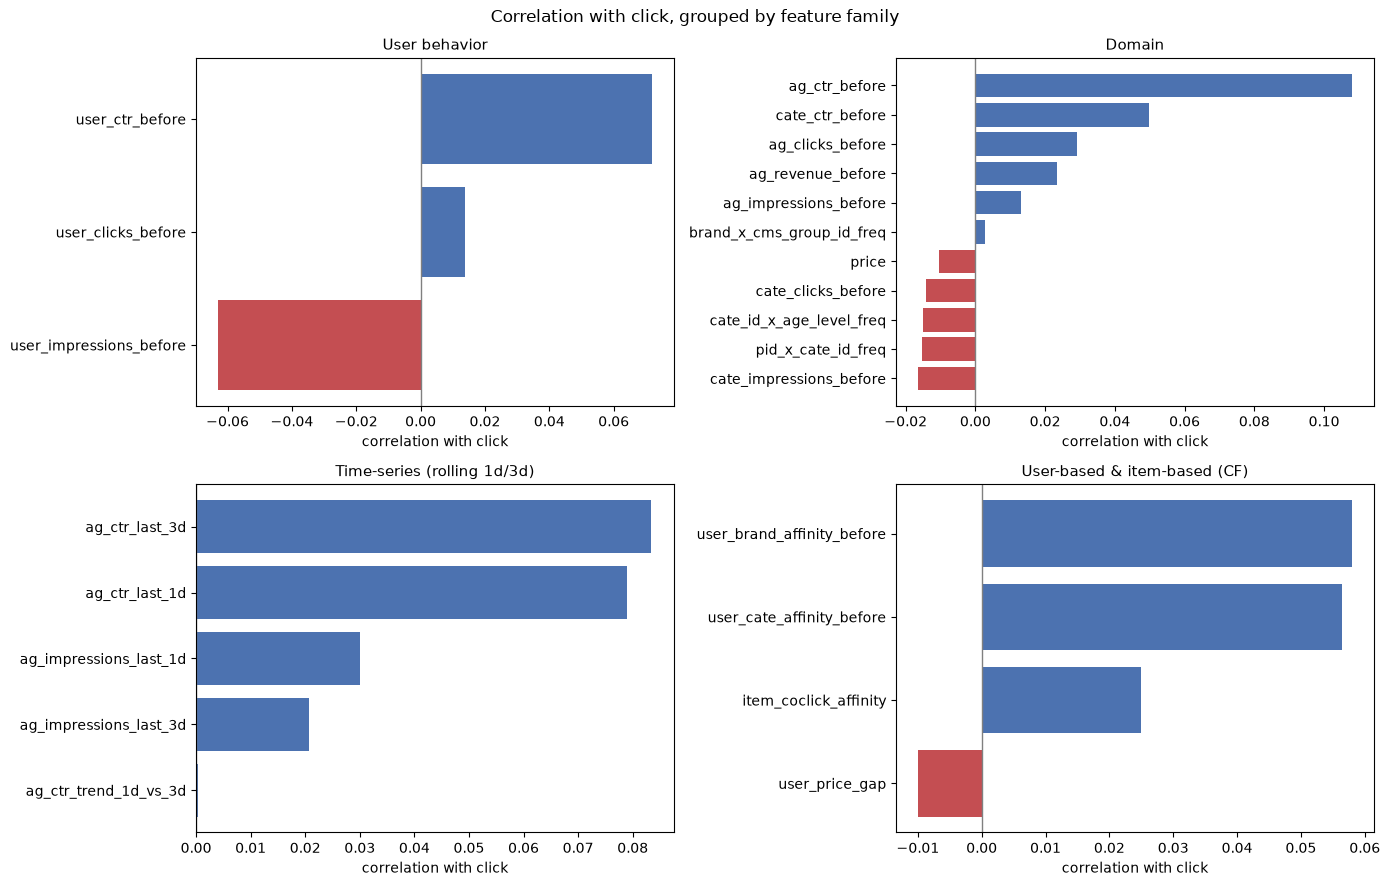

In [25]:
import sys
sys.path.insert(0, "..")

gold = pd.read_parquet(GOLD_DIR / "training_features.parquet")

FEATURE_GROUPS = {
    "User behavior": [
        "user_clicks_before", "user_impressions_before", "user_ctr_before",
    ],
    "Domain": [
        "price", "ag_clicks_before", "ag_impressions_before", "ag_ctr_before", "ag_revenue_before",
        "cate_clicks_before", "cate_impressions_before", "cate_ctr_before",
        "pid_x_cate_id_freq", "cate_id_x_age_level_freq", "brand_x_cms_group_id_freq",
    ],
    "Time-series (rolling 1d/3d)": [
        "ag_impressions_last_1d", "ag_ctr_last_1d",
        "ag_impressions_last_3d", "ag_ctr_last_3d", "ag_ctr_trend_1d_vs_3d",
    ],
    "User-based & item-based (CF)": [
        "item_coclick_affinity", "user_cate_affinity_before", "user_brand_affinity_before", "user_price_gap",
    ],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
group_corrs = {}
for (name, cols), ax in zip(FEATURE_GROUPS.items(), axes.flat):
    cols = [c for c in cols if c in gold.columns]
    corr_g = gold[cols].corrwith(gold["click"]).sort_values()
    group_corrs[name] = corr_g
    colors = ["#C44E52" if v < 0 else "#4C72B0" for v in corr_g.values]
    ax.barh(corr_g.index, corr_g.values, color=colors)
    ax.axvline(0, color="grey", linewidth=1)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("correlation with click")

plt.suptitle("Correlation with click, grouped by feature family")
plt.tight_layout()
plt.show()

Exact values per group, ranked by absolute correlation:

In [26]:
for name, s in group_corrs.items():
    print(f"\n{name}")
    print(s.reindex(s.abs().sort_values(ascending=False).index).round(4))


User behavior
user_ctr_before            0.0720
user_impressions_before   -0.0630
user_clicks_before         0.0139
dtype: float64

Domain
ag_ctr_before                0.1081
cate_ctr_before              0.0497
ag_clicks_before             0.0293
ag_revenue_before            0.0235
cate_impressions_before     -0.0165
pid_x_cate_id_freq          -0.0153
cate_id_x_age_level_freq    -0.0150
cate_clicks_before          -0.0142
ag_impressions_before        0.0132
price                       -0.0103
brand_x_cms_group_id_freq    0.0028
dtype: float64

Time-series (rolling 1d/3d)
ag_ctr_last_3d            0.0834
ag_ctr_last_1d            0.0789
ag_impressions_last_1d    0.0300
ag_impressions_last_3d    0.0206
ag_ctr_trend_1d_vs_3d     0.0004
dtype: float64

User-based & item-based (CF)
user_brand_affinity_before    0.0580
user_cate_affinity_before     0.0565
item_coclick_affinity         0.0249
user_price_gap               -0.0100
dtype: float64


**Multicollinearity check** — across all grouped features together (still excluding keys/TE), which pairs move together the most: 

In [27]:
all_grouped_cols = [c for cols in FEATURE_GROUPS.values() for c in cols if c in gold.columns]
corr = gold[all_grouped_cols].corr()

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("corr")
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
)
corr_pairs["abs_corr"] = corr_pairs["corr"].abs()
corr_pairs.sort_values("abs_corr", ascending=False).head(15).drop(columns="abs_corr")

,feature_a,feature_b,corr
193,cate_clicks_before,cate_impressions_before,0.997280
97,ag_clicks_before,ag_impressions_before,0.976973
91,price,user_price_gap,0.939943
362,ag_ctr_last_1d,ag_ctr_last_3d,0.918869
338,ag_impressions_last_1d,ag_impressions_last_3d,0.916294
122,ag_impressions_before,ag_revenue_before,0.811900
99,ag_clicks_before,ag_revenue_before,0.805836
265,pid_x_cate_id_freq,cate_id_x_age_level_freq,0.787348
155,ag_ctr_before,ag_ctr_last_3d,0.748594
108,ag_clicks_before,ag_impressions_last_3d,0.699269


### Fair cross-type ranking: mutual information

Pearson correlation (numeric) and Cramér's V (categorical) are different statistics on
different scales — comparing their raw magnitudes across types isn't a valid way to say which
*feature* matters more, only which matters more *within its own type*. Mutual information
doesn't have that problem: it measures how many bits of information a feature carries about
`click`, on the same scale, whether the feature is continuous or categorical — so numeric and
categorical features can be ranked together, honestly.

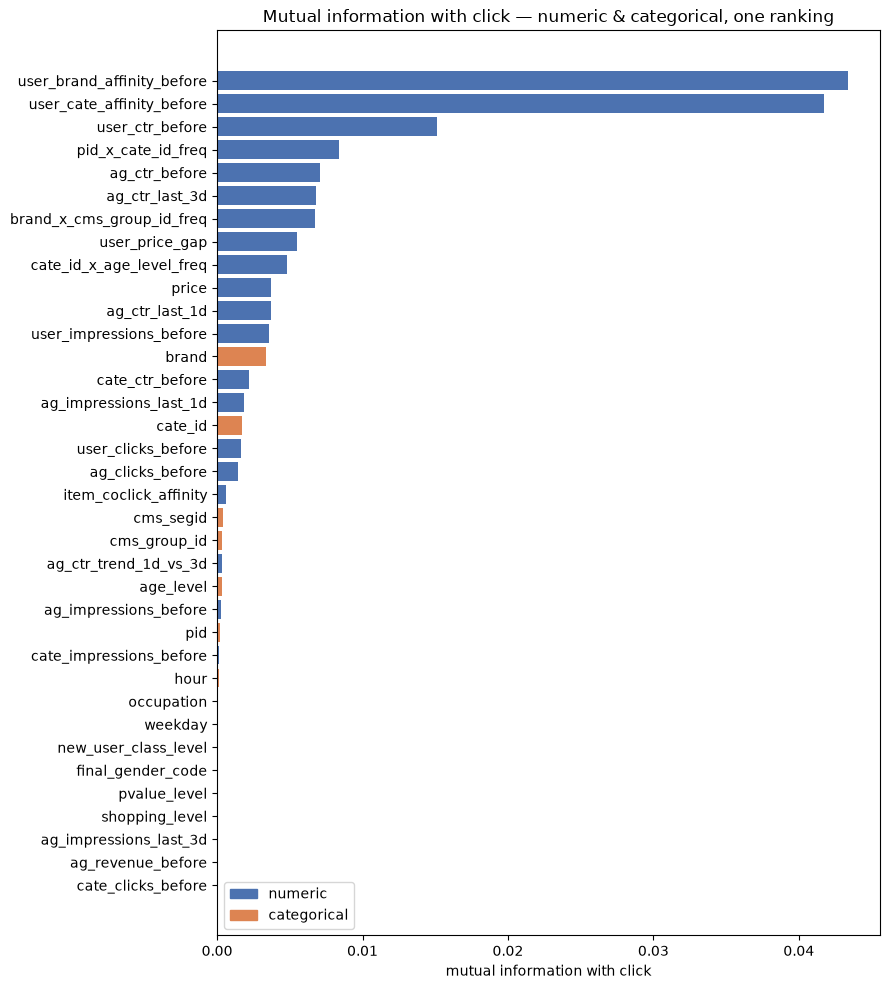

,mutual_info,type
user_brand_affinity_before,0.043412,numeric
user_cate_affinity_before,0.041746,numeric
user_ctr_before,0.015110,numeric
pid_x_cate_id_freq,0.008378,numeric
ag_ctr_before,0.007101,numeric
ag_ctr_last_3d,0.006781,numeric
brand_x_cms_group_id_freq,0.006738,numeric
user_price_gap,0.005519,numeric
cate_id_x_age_level_freq,0.004800,numeric
price,0.003728,numeric


In [28]:
from sklearn.feature_selection import mutual_info_classif
from medallion.gold.features import CATEGORICAL_FEATURES

categorical_mi_cols = [c for c in CATEGORICAL_FEATURES if c in gold.columns]
mi_cols = all_grouped_cols + categorical_mi_cols  # same numeric set as above (no keys/TE) + all categoricals

X_mi = gold[mi_cols].copy()
for c in categorical_mi_cols:
    X_mi[c] = X_mi[c].astype("category").cat.codes

discrete_mask = [c in categorical_mi_cols for c in mi_cols]
mi = mutual_info_classif(X_mi, gold["click"], discrete_features=discrete_mask, random_state=42)

mi_series = pd.Series(mi, index=mi_cols, name="mutual_info").sort_values(ascending=False)
feature_type = pd.Series(
    {c: ("categorical" if c in categorical_mi_cols else "numeric") for c in mi_cols}
)

fig, ax = plt.subplots(figsize=(9, 10))
colors = mi_series.index.map(lambda c: "#DD8452" if c in categorical_mi_cols else "#4C72B0")
ax.barh(mi_series.index[::-1], mi_series.values[::-1], color=colors[::-1])
ax.set_xlabel("mutual information with click")
handles = [
    plt.Rectangle((0, 0), 1, 1, color="#4C72B0", label="numeric"),
    plt.Rectangle((0, 0), 1, 1, color="#DD8452", label="categorical"),
]
ax.legend(handles=handles)
plt.title("Mutual information with click — numeric & categorical, one ranking")
plt.tight_layout()
plt.show()

pd.concat([mi_series, feature_type.rename("type")], axis=1).sort_values("mutual_info", ascending=False)

### Distribution by outcome, per group (numeric only)

For each numeric feature in each group: histogram split by `click` (0 vs. 1), with a
Mann-Whitney U p-value **and Cliff's delta** (rank-biserial correlation, derived directly from
the same U statistic) in the title. The p-value alone is misleading at n=300k — almost every
feature clears p < 0.001 regardless of whether the difference is meaningful. Cliff's delta fixes
that: it's bounded [-1, 1], doesn't inflate with sample size, and directly answers "how different
are the two distributions" rather than "is there *any* detectable difference." Thresholds
(Romano et al.): |δ| < 0.147 negligible, < 0.33 small, < 0.474 medium, else large.

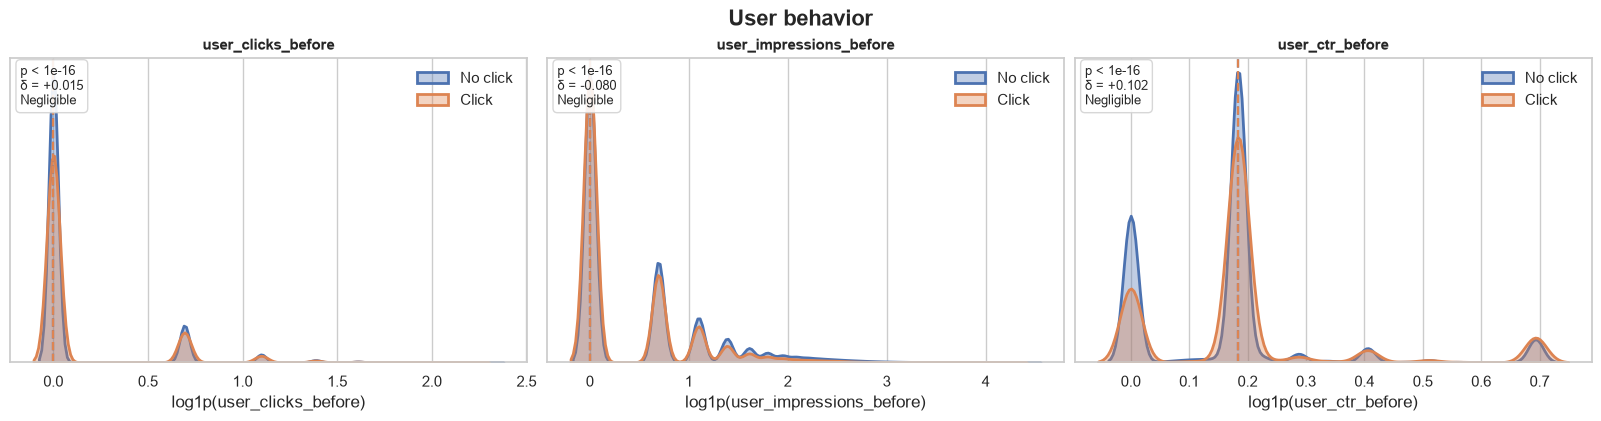

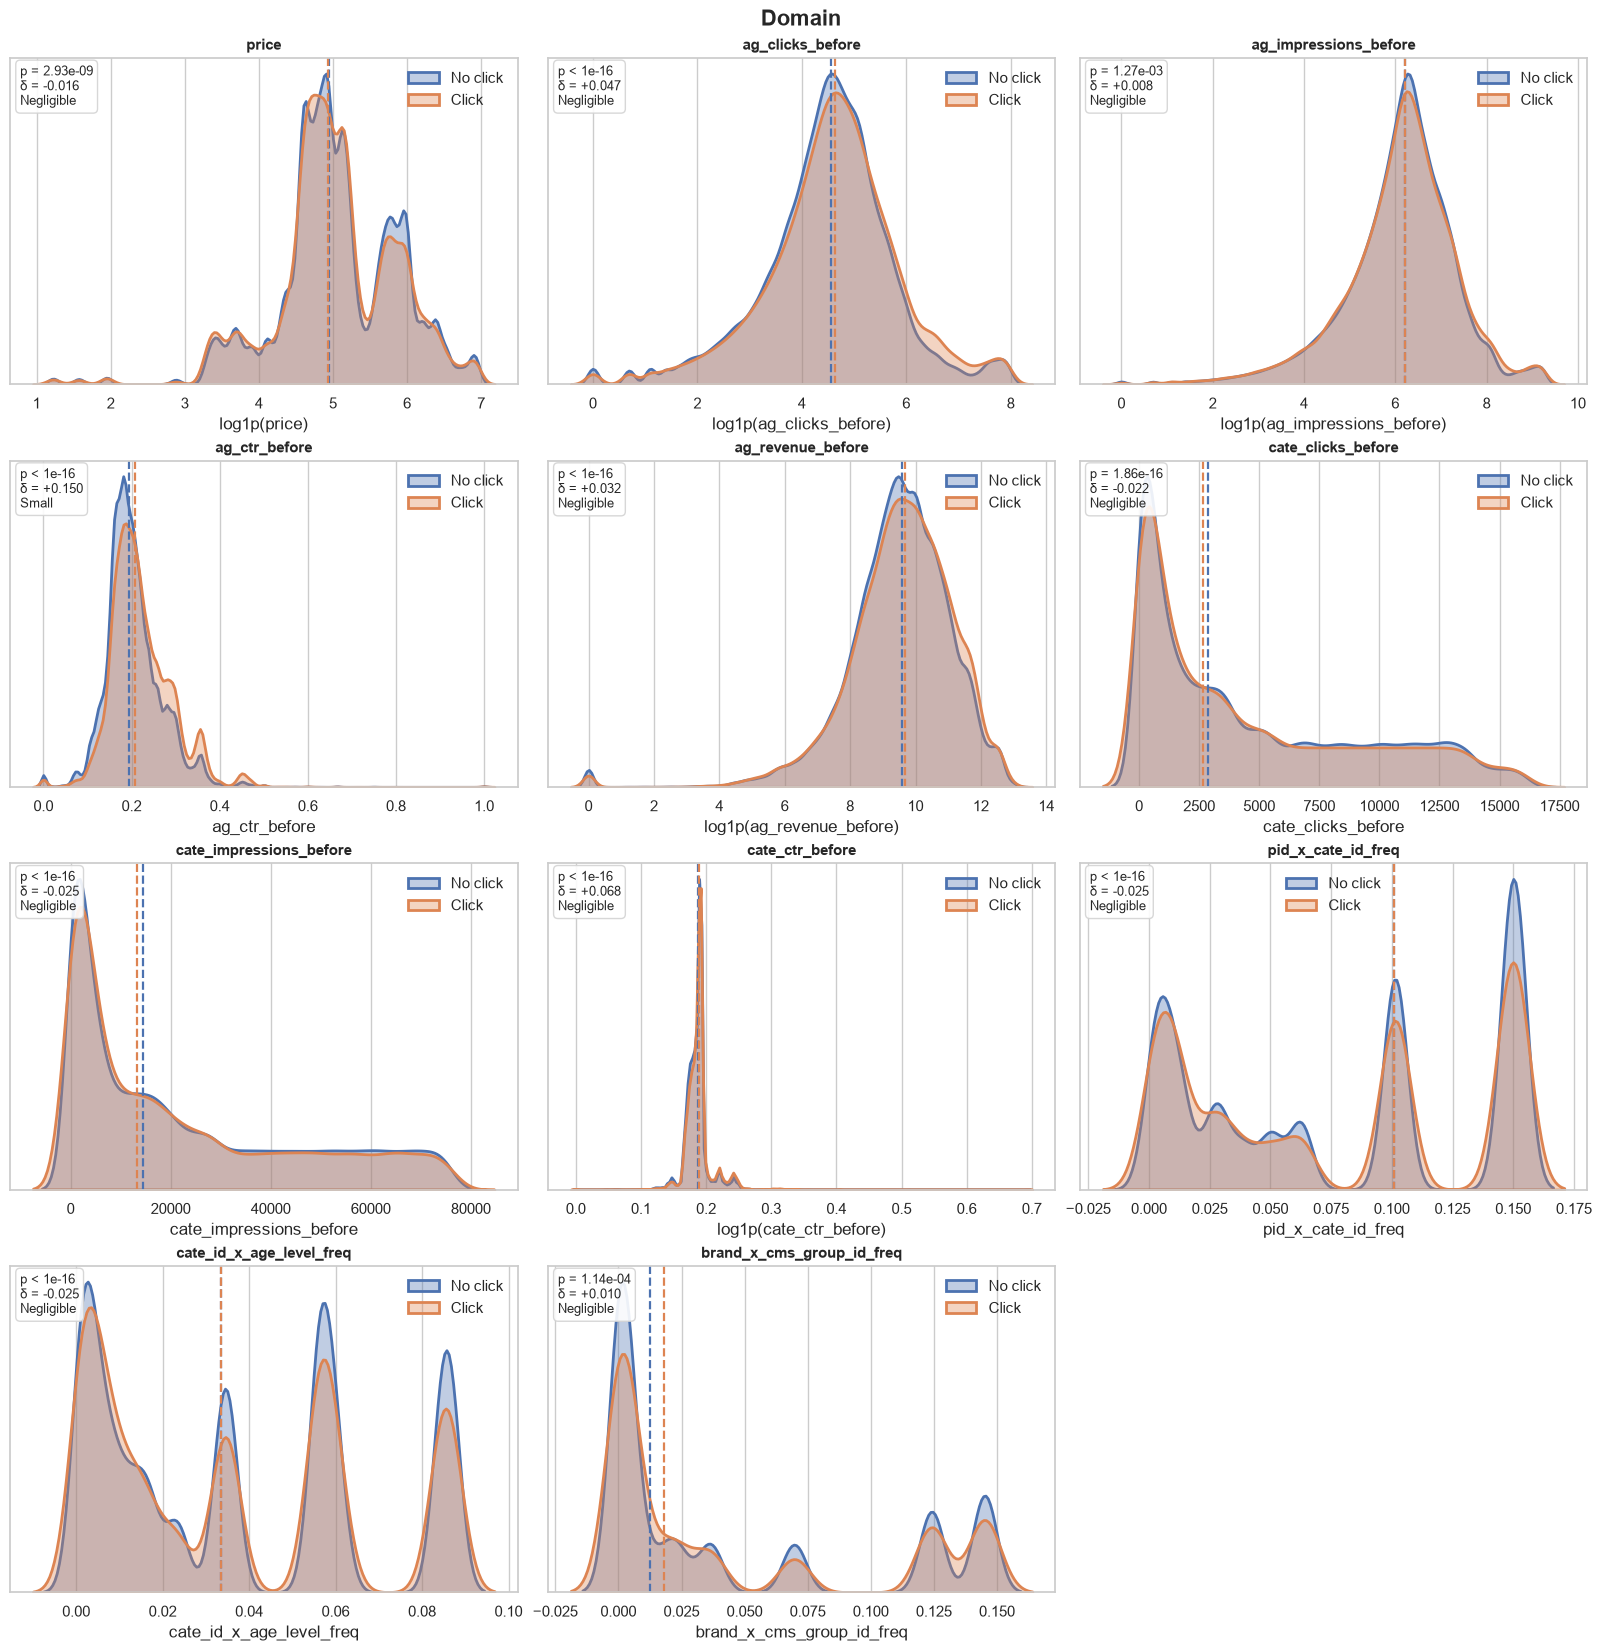

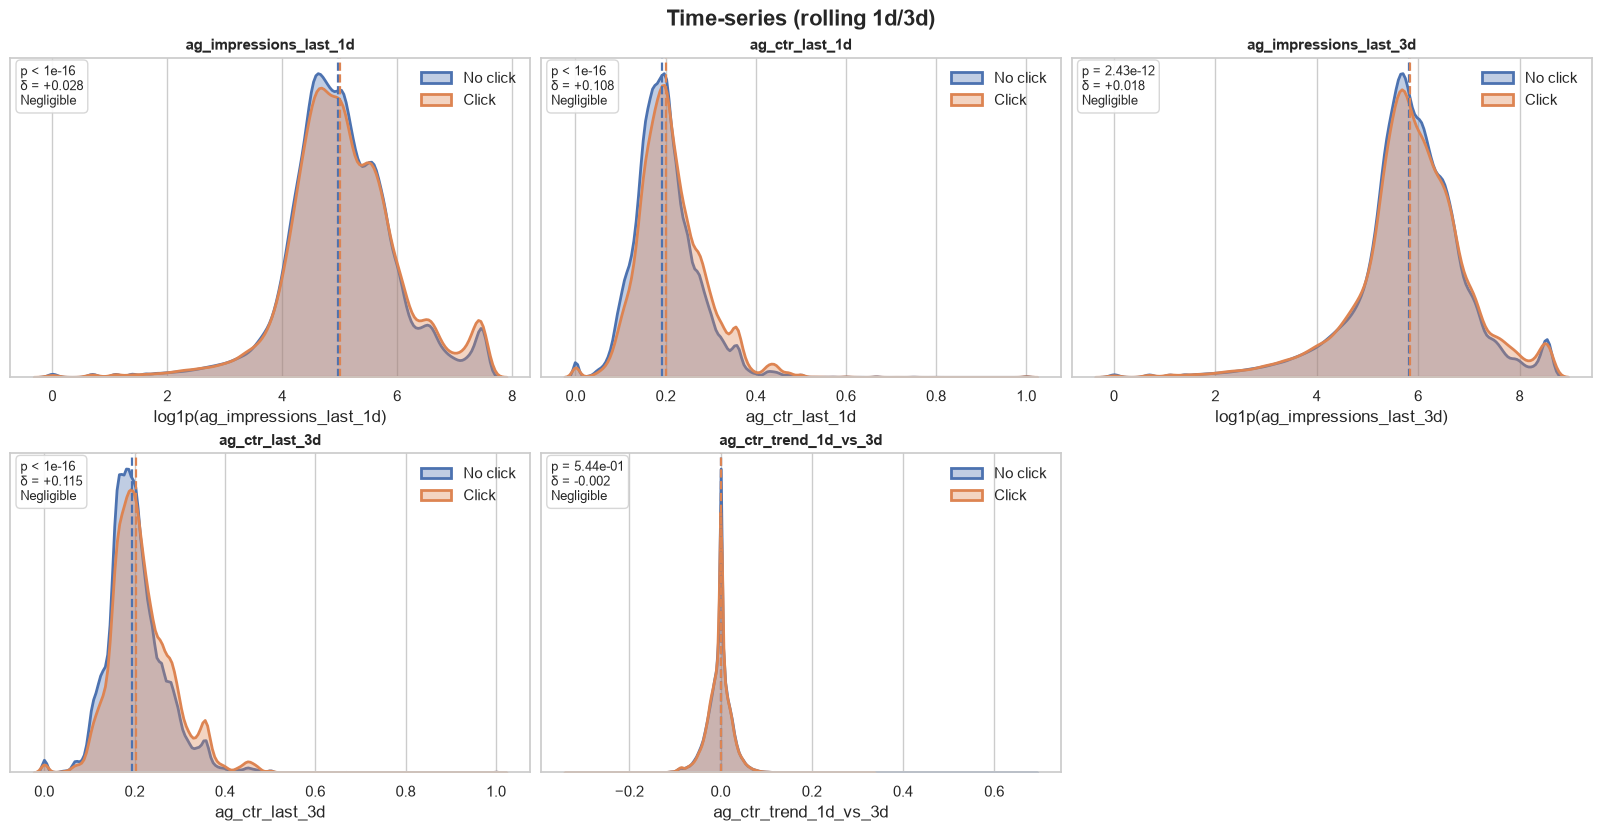

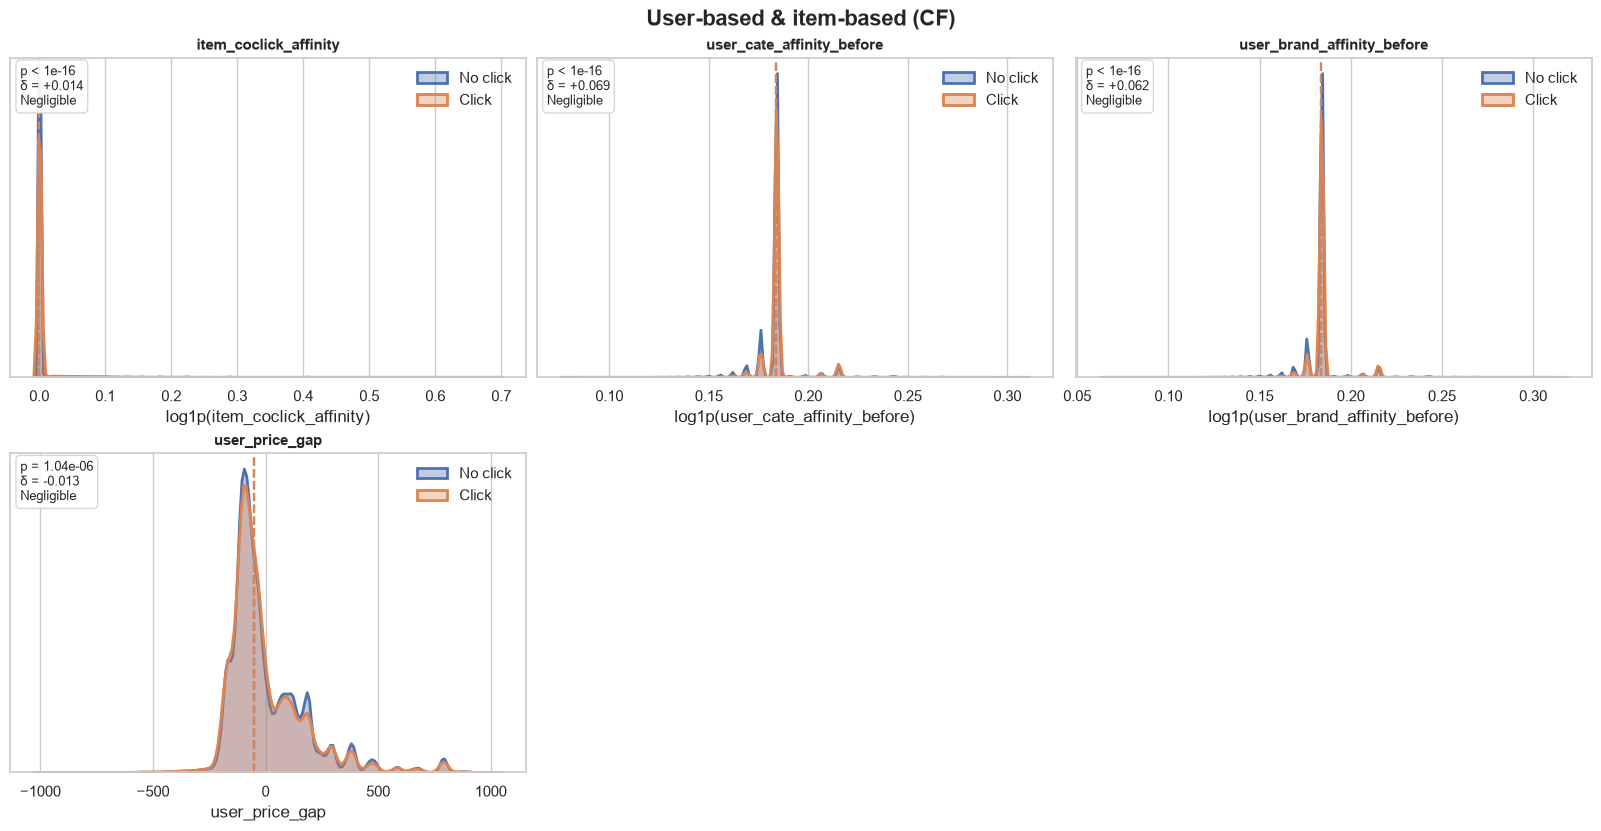

,group,feature,p_value,cliffs_delta,effect
6,Domain,ag_ctr_before,0.000,0.150,Small
17,Time-series (rolling 1d/3d),ag_ctr_last_3d,0.000,0.115,Negligible
15,Time-series (rolling 1d/3d),ag_ctr_last_1d,0.000,0.108,Negligible
2,User behavior,user_ctr_before,0.000,0.102,Negligible
1,User behavior,user_impressions_before,0.000,-0.080,Negligible
20,User-based & item-based (CF),user_cate_affinity_before,0.000,0.069,Negligible
10,Domain,cate_ctr_before,0.000,0.068,Negligible
21,User-based & item-based (CF),user_brand_affinity_before,0.000,0.062,Negligible
4,Domain,ag_clicks_before,0.000,0.047,Negligible
7,Domain,ag_revenue_before,0.000,0.032,Negligible


In [34]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid", context="notebook")


# --------------------------------------------------
# Statistics
# --------------------------------------------------

def cliffs_delta_from_u(u_stat, n1, n2):
    return 2 * u_stat / (n1 * n2) - 1


def effect_label(delta):
    d = abs(delta)
    if d < 0.147:
        return "Negligible"
    elif d < 0.33:
        return "Small"
    elif d < 0.474:
        return "Medium"
    return "Large"


# --------------------------------------------------
# Plotting
# --------------------------------------------------

def plot_group_distributions(
    group_name,
    cols,
    dataframe=gold,
    target="click",
    ncols=3,
    log_skew=True,
):

    cols = [c for c in cols if c in dataframe.columns]

    clicked = dataframe[dataframe[target] == 1]
    non_clicked = dataframe[dataframe[target] == 0]

    nrows = math.ceil(len(cols) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5.3 * ncols, 4.1 * nrows),
        constrained_layout=True,
    )

    axes = np.array(axes).reshape(-1)

    effect_rows = []

    for ax, col in zip(axes, cols):

        c0 = non_clicked[col].dropna()
        c1 = clicked[col].dropna()

        # ------------------------------------------
        # Optional log transform for heavy tails
        # ------------------------------------------

        xlabel = col

        if (
            log_skew
            and c0.min() >= 0
            and c1.min() >= 0
            and abs(dataframe[col].skew()) > 1.5
        ):
            c0_plot = np.log1p(c0)
            c1_plot = np.log1p(c1)
            xlabel = f"log1p({col})"
        else:
            c0_plot = c0
            c1_plot = c1

        # ------------------------------------------
        # Mann-Whitney + Cliff
        # ------------------------------------------

        u, p = mannwhitneyu(
            c1,
            c0,
            alternative="two-sided",
        )

        delta = cliffs_delta_from_u(
            u,
            len(c1),
            len(c0),
        )

        effect_rows.append(
            {
                "group": group_name,
                "feature": col,
                "p_value": p,
                "cliffs_delta": delta,
                "effect": effect_label(delta),
            }
        )

        # ------------------------------------------
        # KDE
        # ------------------------------------------

        sns.kdeplot(
            c0_plot,
            fill=True,
            alpha=0.35,
            linewidth=2,
            color="#4C72B0",
            label="No click",
            ax=ax,
        )

        sns.kdeplot(
            c1_plot,
            fill=True,
            alpha=0.35,
            linewidth=2,
            color="#DD8452",
            label="Click",
            ax=ax,
        )

        # ------------------------------------------
        # Median lines
        # ------------------------------------------

        ax.axvline(
            np.median(c0_plot),
            color="#4C72B0",
            linestyle="--",
            linewidth=1.6,
        )

        ax.axvline(
            np.median(c1_plot),
            color="#DD8452",
            linestyle="--",
            linewidth=1.6,
        )

        # ------------------------------------------
        # Annotation
        # ------------------------------------------

        if p < 1e-16:
            p_text = "p < 1e-16"
        else:
            p_text = f"p = {p:.2e}"

        stats_text = (
            f"{p_text}\n"
            f"δ = {delta:+.3f}\n"
            f"{effect_label(delta)}"
        )

        ax.text(
            0.02,
            0.98,
            stats_text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(
                facecolor="white",
                edgecolor="lightgray",
                alpha=0.9,
                boxstyle="round,pad=0.35",
            ),
        )

        # ------------------------------------------
        # Cosmetics
        # ------------------------------------------

        ax.set_title(col, fontsize=11, fontweight="bold")

        ax.set_xlabel(xlabel)

        ax.set_ylabel("")

        ax.set_yticks([])

        ax.grid(axis="y", alpha=0.15)

        ax.legend(frameon=False)

    # remove empty panels

    for ax in axes[len(cols):]:
        fig.delaxes(ax)

    fig.suptitle(
        group_name,
        fontsize=16,
        fontweight="bold",
    )

    plt.show()

    return effect_rows


# --------------------------------------------------
# Run everything
# --------------------------------------------------

effect_rows = []

for group, cols in FEATURE_GROUPS.items():

    effect_rows.extend(
        plot_group_distributions(
            group_name=group,
            cols=cols,
        )
    )

effect_table = (
    pd.DataFrame(effect_rows)
    .sort_values(
        "cliffs_delta",
        key=np.abs,
        ascending=False,
    )
)

effect_table["p_value"] = effect_table["p_value"].round(3)
effect_table["cliffs_delta"] = effect_table["cliffs_delta"].round(3)

display(effect_table)

### Insight: p-value vs. Cliff's δ trả lời hai câu hỏi khác nhau

- **p-value (Mann–Whitney U)** trả lời: *"Feature này có khác nhau giữa click và non-click không?"*
- **Cliff's δ** trả lời: *"Khác nhau nhiều hay ít?"*

Với n=300k, gần như mọi feature đều có p-value cực nhỏ (câu trả lời cho câu hỏi 1 luôn là "có") —
nên **δ mới là con số quyết định**, không phải p-value. Bảng dưới đây là toàn bộ 23 feature số,
xếp theo |δ| giảm dần, dùng số liệu thật từ `effect_table` ở trên:

| Feature | p-value | Cliff's δ | Kết luận |
|---|---|---|---|
| `ag_ctr_before` | <1e-300 | **0.150** | Có khác biệt, mức ảnh hưởng **nhỏ** — feature duy nhất vượt ngưỡng negligible |
| `ag_ctr_last_3d` | <1e-300 | 0.115 | Có ý nghĩa thống kê nhưng ảnh hưởng **không đáng kể** |
| `ag_ctr_last_1d` | <1e-300 | 0.108 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `user_ctr_before` | <1e-300 | 0.102 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `user_impressions_before` | 7.7e-251 | -0.080 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `user_cate_affinity_before` | 3.6e-295 | 0.069 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `cate_ctr_before` | 2.4e-148 | 0.068 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `user_brand_affinity_before` | 4.4e-257 | 0.062 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `ag_clicks_before` | 4.1e-71 | 0.047 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `ag_revenue_before` | 1.1e-33 | 0.032 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `ag_impressions_last_1d` | 2.2e-26 | 0.028 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `cate_impressions_before` | 7.1e-22 | -0.025 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `pid_x_cate_id_freq` | 2.2e-21 | -0.025 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `cate_id_x_age_level_freq` | 4.5e-21 | -0.025 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `cate_clicks_before` | 1.9e-16 | -0.022 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `ag_impressions_last_3d` | 2.4e-12 | 0.018 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `price` | 2.9e-09 | -0.016 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `user_clicks_before` | 4.1e-21 | 0.015 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `item_coclick_affinity` | 1.0e-54 | 0.014 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `user_price_gap` | 1.0e-06 | -0.013 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `brand_x_cms_group_id_freq` | 1.1e-04 | 0.010 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `ag_impressions_before` | 1.3e-03 | 0.008 | Có ý nghĩa thống kê nhưng ảnh hưởng không đáng kể |
| `ag_ctr_trend_1d_vs_3d` | **0.544** | -0.002 | **Không** khác biệt — cả p-value lẫn δ đều "trượt", feature này không tách biệt click/non-click ở mức đơn lẻ |

**Điểm mấu chốt cho bài CTR prediction này**: nếu chỉ lọc feature bằng p-value (cách làm phổ
biến nhưng sai ở quy mô n=300k), 22/23 feature đều "pass" — gần như vô dụng để loại bớt feature.
Lọc bằng |δ| ≥ 0.147 (ngưỡng "small" trở lên) thì chỉ còn đúng **1 feature** (`ag_ctr_before`)
sống sót — cho thấy rõ: **không có feature nào đơn lẻ nào phân tách được click/non-click ở mức
đủ lớn để tự nó "chọn" được**. Đây chính là lý do model gradient-boosting (LightGBM/XGBoost) vẫn
đạt AUC ~0.61 dù không feature nào riêng lẻ vượt "small" — sức mạnh nằm ở **tổ hợp phi tuyến của
nhiều tín hiệu yếu**, không nằm ở bất kỳ feature đơn lẻ nào.

### Final combined ranking (numeric features) - optional

Three metrics, three different questions about the same feature — combined into one score so
the numeric features can be ranked once instead of three separate times.

| Metric | Definition | Range | "This discriminates" rule of thumb |
|---|---|---|---|
| **\|Pearson r\|** | Linear association between the feature and `click` (treating 0/1 as numeric). Misses any non-straight-line relationship entirely. | 0 to 1 (abs.) | Cohen (1988): < 0.1 negligible, 0.1–0.3 small, 0.3–0.5 medium, > 0.5 large |
| **Normalized MI** (MI ÷ H(click)) | Share of `click`'s entropy (uncertainty) that knowing this feature removes. Catches *any* dependency, linear or not — the most general of the three. | 0 (independent) to 1 (fully determines click) | No fixed universal threshold — `click` is inherently noisy (H≈0.72 bits at 20% CTR), so read NMI *relative to the other features here*, not against an absolute bar |
| **\|Cliff's δ\|** | P(random clicked value > random non-clicked value) − P(the reverse). A rank-based effect size: how separated are the two distributions, regardless of shape. | 0 to 1 (abs.) | Romano et al. (2006): < 0.147 negligible, < 0.33 small, < 0.474 medium, else large |

Each metric is min-max normalized to [0, 1] first (their raw scales aren't comparable), then
combined as an equal-weighted average — no metric has a stronger claim to being "the" right
answer than the others, since each is blind to something the other two catch (r misses
non-linearity, NMI has no effect-size convention, δ ignores magnitude beyond rank). Weights are
a plain dict below — adjust them if you want to favor one lens over another.

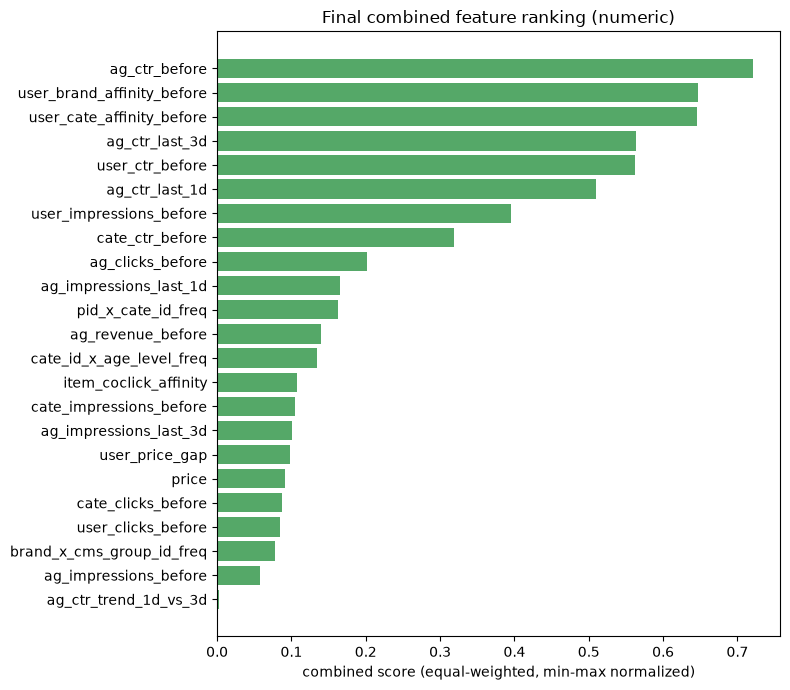

,abs_corr,nmi,abs_delta,final_score
ag_ctr_before,0.1081,0.0098,0.1504,0.7212
user_brand_affinity_before,0.0580,0.0601,0.0621,0.6473
user_cate_affinity_before,0.0565,0.0578,0.0691,0.6455
ag_ctr_last_3d,0.0834,0.0094,0.1154,0.5639
user_ctr_before,0.0720,0.0209,0.1017,0.5618
ag_ctr_last_1d,0.0789,0.0051,0.1079,0.5095
user_impressions_before,0.0630,0.0050,0.0795,0.3960
cate_ctr_before,0.0497,0.0030,0.0684,0.3190
ag_clicks_before,0.0293,0.0020,0.0470,0.2022
ag_impressions_last_1d,0.0300,0.0026,0.0280,0.1650


In [11]:
WEIGHTS = {"abs_corr": 1 / 3, "nmi": 1 / 3, "abs_delta": 1 / 3}

abs_corr = pd.concat(group_corrs.values()).abs()
abs_corr = abs_corr[~abs_corr.index.duplicated()]

p_click = gold["click"].mean()
h_click = -(p_click * np.log2(p_click) + (1 - p_click) * np.log2(1 - p_click))
nmi = mi_series.drop(index=categorical_mi_cols, errors="ignore") / h_click

abs_delta = effect_table.set_index("feature")["cliffs_delta"].abs()

combined = pd.DataFrame({"abs_corr": abs_corr, "nmi": nmi, "abs_delta": abs_delta})

def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

normed = combined.apply(minmax)
combined["final_score"] = sum(normed[col] * w for col, w in WEIGHTS.items())
combined = combined.sort_values("final_score", ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(combined.index[::-1], combined["final_score"].values[::-1], color="#55A868")
ax.set_xlabel("combined score (equal-weighted, min-max normalized)")
plt.title("Final combined feature ranking (numeric)")
plt.tight_layout()
plt.show()

combined.round(4)

## 6. Customer overview

In [12]:
user_stats = df.groupby("userid").agg(impressions=("click", "size"), clicks=("click", "sum"))
user_stats["clicked_at_least_once"] = user_stats["clicks"] > 0

# dim_user is the full raw registered-user catalog (1M+); only a fraction of those
# users actually appear in this impression-log sample, so keep the two counts distinct.
active_users = dim_user[dim_user["userid"].isin(user_stats.index)]

top10_cut = user_stats["impressions"].quantile(0.9)
top10_users = user_stats[user_stats["impressions"] >= top10_cut]

customer_overview = pd.DataFrame({
    "value": [
        dim_user["userid"].nunique(),
        user_stats.shape[0],
        f"{user_stats.shape[0] / dim_user['userid'].nunique():.2%}",
        f"{user_stats['impressions'].mean():.2f}",
        f"{user_stats['clicks'].mean():.2f}",
        f"{user_stats['clicked_at_least_once'].mean():.2%}",
        int((user_stats['impressions'] == 1).sum()),
        f"{(user_stats['impressions'] == 1).mean():.2%}",
        f"{top10_users['impressions'].sum() / user_stats['impressions'].sum():.2%}",
        f"{top10_users['clicks'].sum() / user_stats['clicks'].sum():.2%}",
    ],
}, index=[
    "registered users (full dim_user catalog)", "active users (appear in impression log)",
    "% of catalog that's active", "avg impressions / active user", "avg clicks / active user",
    "% active users with >=1 click", "active users seen exactly once", "% active users seen exactly once",
    "top 10% most-active users' share of impressions", "top 10% most-active users' share of clicks",
])
customer_overview

,value
registered users (full dim_user catalog),1061768
active users (appear in impression log),174283
% of catalog that's active,16.41%
avg impressions / active user,1.72
avg clicks / active user,0.34
% active users with >=1 click,28.96%
active users seen exactly once,115399
% active users seen exactly once,66.21%
top 10% most-active users' share of impressions,39.42%
top 10% most-active users' share of clicks,35.23%


## 7. Customer segments

CTR by demographic cut (active users only — those appearing in the impression log).

C:\Users\TommyPhan_Exp\AppData\Local\Temp\ipykernel_15512\2025255191.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=8)
C:\Users\TommyPhan_Exp\AppData\Local\Temp\ipykernel_15512\2025255191.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=8)
C:\Users\TommyPhan_Exp\AppData\Local\Temp\ipykernel_15512\2025255191.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=8)


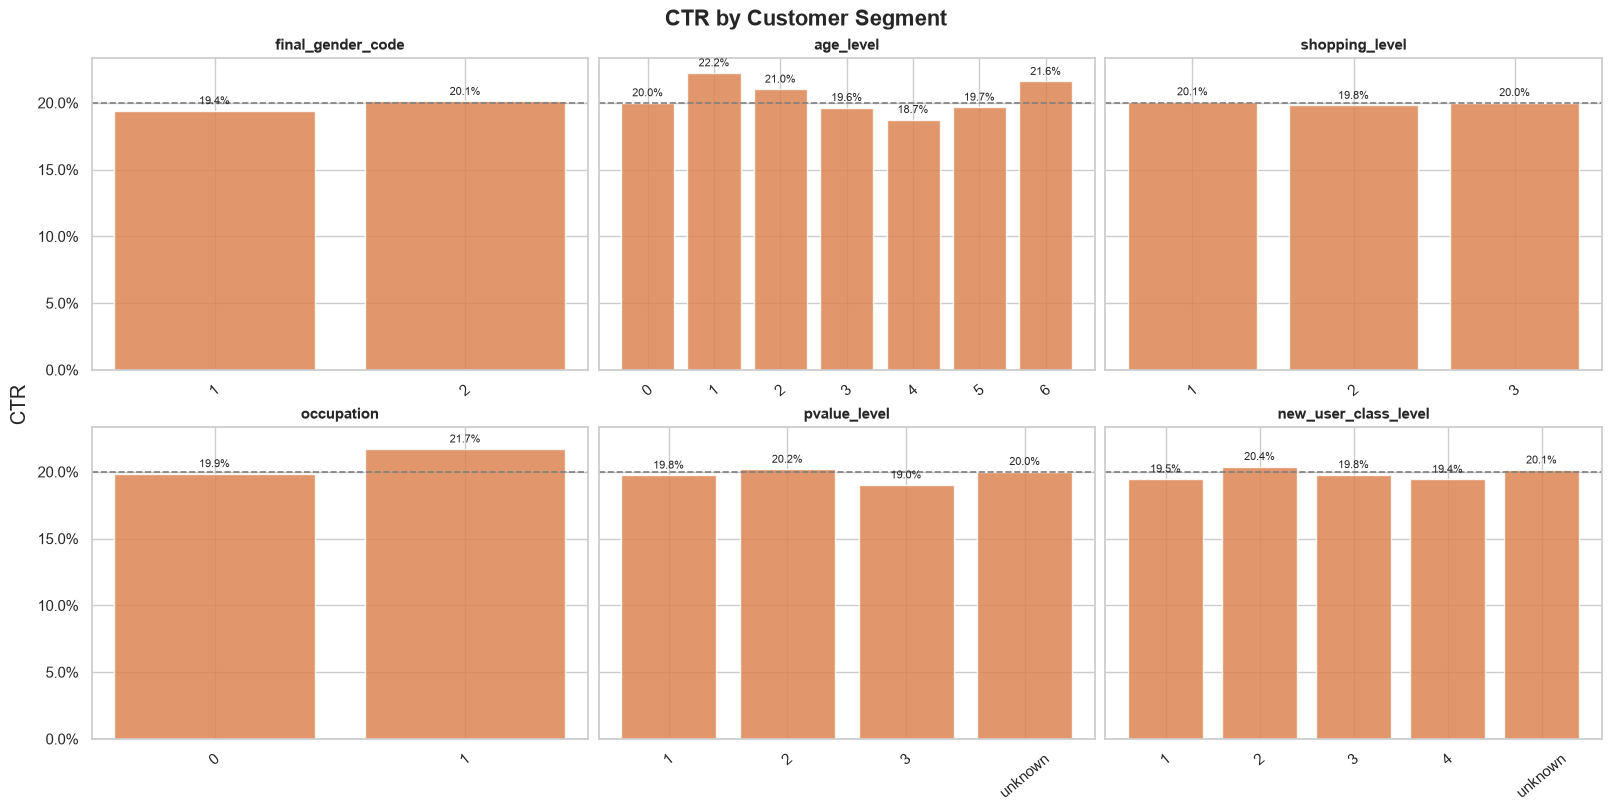

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

segment_cols = [
    "final_gender_code",
    "age_level",
    "shopping_level",
    "occupation",
    "pvalue_level",
    "new_user_class_level",
]

overall_ctr = df["click"].mean()

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 8),
    sharey=True,
    constrained_layout=True,
)

axes = axes.ravel()

for ax, col in zip(axes, segment_cols):

    ctr = (
        df.groupby(col)["click"]
        .mean()
        .sort_index()
    )

    x = ctr.index.astype(str)
    y = ctr.values

    bars = ax.bar(
        x,
        y,
        color="#DD8452",
        alpha=0.85,
    )

    # Overall CTR reference
    ax.axhline(
        overall_ctr,
        color="gray",
        linestyle="--",
        linewidth=1.2,
        # label=f"Overall ({overall_ctr:.1%})",
    )

    # Value labels
    ax.bar_label(
        bars,
        labels=[f"{v:.1%}" for v in y],
        padding=3,
        fontsize=8,
    )

    ax.set_title(col, fontsize=11, weight="bold")
    ax.tick_params(axis="x", rotation=40)

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

    ax.legend(frameon=False, fontsize=8)

# Shared y-axis label
fig.supylabel("CTR")

fig.suptitle(
    "CTR by Customer Segment",
    fontsize=16,
    fontweight="bold",
)

plt.show()

## 8. Engagement distribution

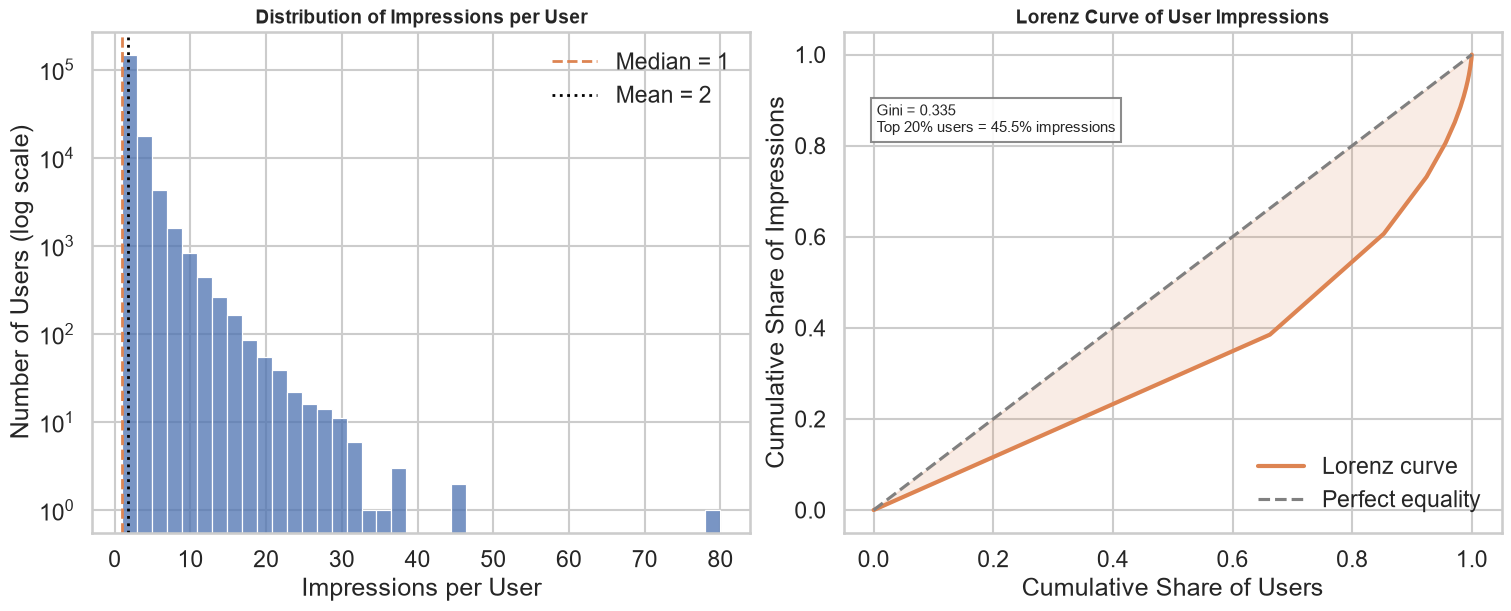

Gini coefficient : 0.335
Top 20% users contribute 45.52% of impressions.


In [39]:

sns.set_theme(style="whitegrid", context="talk")

# -------------------------------------------------
# Gini coefficient
# -------------------------------------------------

def gini(x):
    x = np.sort(np.asarray(x))
    n = len(x)
    cumx = np.cumsum(x)

    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n


# -------------------------------------------------
# Data
# -------------------------------------------------

imp = user_stats["impressions"].values

median = np.median(imp)
mean = np.mean(imp)

gini_coeff = gini(imp)

# Lorenz curve
imp_sorted = np.sort(imp)
cum_imp = np.cumsum(imp_sorted) / imp_sorted.sum()
cum_users = np.arange(1, len(imp_sorted)+1) / len(imp_sorted)

# Top 20% contribution
top20 = int(0.2 * len(imp_sorted))
top20_share = imp_sorted[-top20:].sum() / imp_sorted.sum()


# -------------------------------------------------
# Plot
# -------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15,6),
    constrained_layout=True,
)

# =================================================
# Histogram
# =================================================

sns.histplot(
    imp,
    bins=40,
    color="#4C72B0",
    edgecolor="white",
    ax=axes[0]
)

axes[0].set_yscale("log")

axes[0].axvline(
    median,
    color="#DD8452",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median:.0f}"
)

axes[0].axvline(
    mean,
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Mean = {mean:.0f}"
)

axes[0].set_title("Distribution of Impressions per User", fontsize=14, weight="bold")

axes[0].set_xlabel("Impressions per User")

axes[0].set_ylabel("Number of Users (log scale)")

axes[0].legend(frameon=False)


# =================================================
# Lorenz curve
# =================================================

axes[1].plot(
    cum_users,
    cum_imp,
    linewidth=3,
    color="#DD8452",
    label="Lorenz curve"
)

axes[1].plot(
    [0,1],
    [0,1],
    "--",
    color="gray",
    label="Perfect equality"
)

axes[1].fill_between(
    cum_users,
    cum_imp,
    cum_users,
    alpha=.15,
    color="#DD8452"
)

axes[1].text(
    0.05,
    0.80,
    f"Gini = {gini_coeff:.3f}\n"
    f"Top 20% users = {top20_share:.1%} impressions",
    transform=axes[1].transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        alpha=.9,
        edgecolor="gray"
    )
)

axes[1].set_title(
    "Lorenz Curve of User Impressions",
    fontsize=14,
    weight="bold"
)

axes[1].set_xlabel("Cumulative Share of Users")

axes[1].set_ylabel("Cumulative Share of Impressions")

axes[1].legend(frameon=False)

plt.show()

print(f"Gini coefficient : {gini_coeff:.3f}")
print(f"Top 20% users contribute {top20_share:.2%} of impressions.")

         Group  Users  Impressions  Clicks       CTR
0     Top 0-5%   8714        62680    9617  0.153430
1    Top 5-10%   8714        30722    6267  0.203991
2   Top 10-20%  17428        43143    9119  0.211367
3   Top 20-50%  52285        76313   16415  0.215101
4  Top 50-100%  87142        87142   18582  0.213238


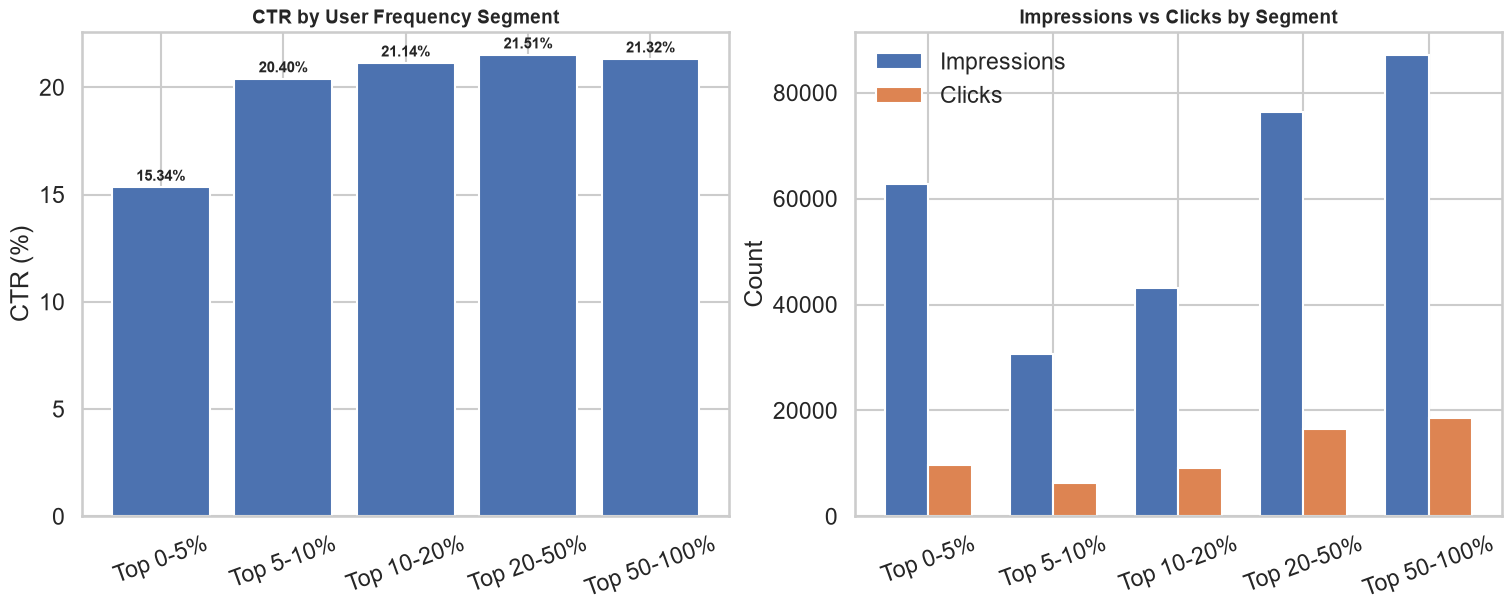

In [41]:
# -------------------------------------------------
# CTR theo disjoint buckets (segment riêng biệt)
# -------------------------------------------------

# Định nghĩa các mốc cắt (percentile ranges)
bucket_edges = [0, 0.05, 0.10, 0.20, 0.50, 1.00]
bucket_labels = ["Top 0-5%", "Top 5-10%", "Top 10-20%", "Top 20-50%", "Top 50-100%"]

df = user_stats.sort_values("impressions", ascending=False).reset_index(drop=True)
n = len(df)

results = []
for i in range(len(bucket_edges) - 1):
    start = int(bucket_edges[i] * n)
    end = int(bucket_edges[i+1] * n)
    group = df.iloc[start:end]

    total_impressions = group["impressions"].sum()
    total_clicks = group["clicks"].sum()
    ctr = total_clicks / total_impressions if total_impressions > 0 else 0

    results.append({
        "Group": bucket_labels[i],
        "Users": end - start,
        "Impressions": total_impressions,
        "Clicks": total_clicks,
        "CTR": ctr
    })

ctr_buckets = pd.DataFrame(results)
print(ctr_buckets)


# -------------------------------------------------
# Plot: CTR by frequency segment
# -------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

# --- Bar chart: CTR theo nhóm ---
bars = axes[0].bar(
    ctr_buckets["Group"],
    ctr_buckets["CTR"] * 100,
    color="#4C72B0",
    edgecolor="white"
)

for bar, ctr in zip(bars, ctr_buckets["CTR"]):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{ctr:.2%}",
        ha="center",
        fontsize=11,
        weight="bold"
    )

axes[0].set_title("CTR by User Frequency Segment", fontsize=14, weight="bold")
axes[0].set_ylabel("CTR (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=20)

# --- Dual axis: Impressions vs Clicks vs CTR line ---
ax2 = axes[1]
x = np.arange(len(ctr_buckets))
width = 0.35

ax2.bar(x - width/2, ctr_buckets["Impressions"], width, label="Impressions", color="#4C72B0")
ax2.bar(x + width/2, ctr_buckets["Clicks"], width, label="Clicks", color="#DD8452")

ax2.set_xticks(x)
ax2.set_xticklabels(ctr_buckets["Group"], rotation=20)
ax2.set_ylabel("Count")
ax2.set_title("Impressions vs Clicks by Segment", fontsize=14, weight="bold")
ax2.legend(frameon=False)

plt.show()

In [45]:
user_stats = df.groupby("userid").agg(impressions=("click", "size", "ad"), clicks=("click", "sum"))
user_stats["clicked_at_least_once"] = user_stats["clicks"] > 0


,impressions,clicks,clicked_at_least_once
userid,,,
11,1,0,False
25,1,0,False
26,1,1,True
27,1,0,False
33,3,1,True
...,...,...,...
1141714,5,3,True
1141718,1,0,False
1141723,1,0,False


In [43]:
# -------------------------------------------------
# User diversity: number of unique ad_groups
# -------------------------------------------------

user_adgroup_stats = (
    df.groupby("userid")
    .agg(
        n_adgroups=("adgroup_id", "nunique"),
        impressions=("adgroup_id", "count"),
        clicks=("clk", "sum")
    )
    .reset_index()
)

# CTR per user
user_adgroup_stats["CTR"] = (
    user_adgroup_stats["clicks"] /
    user_adgroup_stats["impressions"]
)


# -------------------------------------------------
# CTR theo disjoint buckets của số lượng ad_group
# -------------------------------------------------

bucket_edges = [0, 0.05, 0.10, 0.20, 0.50, 1.00]
bucket_labels = [
    "Top 0-5%",
    "Top 5-10%",
    "Top 10-20%",
    "Top 20-50%",
    "Top 50-100%"
]


df_seg = (
    user_adgroup_stats
    .sort_values("n_adgroups", ascending=False)
    .reset_index(drop=True)
)

n = len(df_seg)

results = []

for i in range(len(bucket_edges)-1):

    start = int(bucket_edges[i] * n)
    end = int(bucket_edges[i+1] * n)

    group = df_seg.iloc[start:end]

    total_impressions = group["impressions"].sum()
    total_clicks = group["clicks"].sum()

    ctr = (
        total_clicks / total_impressions
        if total_impressions > 0 else 0
    )

    results.append({
        "Group": bucket_labels[i],
        "Users": len(group),
        "Avg unique adgroups": group["n_adgroups"].mean(),
        "Impressions": total_impressions,
        "Clicks": total_clicks,
        "CTR": ctr
    })


ctr_adgroup_bucket = pd.DataFrame(results)

print(ctr_adgroup_bucket)

KeyError: 'userid'

## 9. Ad performance features (`ag_*`)

`ag_clicks_before`/`ag_impressions_before`/`ag_ctr_before` are cumulative-to-date, and
`ag_ctr_last_1d`/`_3d` are rolling windows — every row carries the ad's state *as of that
impression*. Taking each ad's last row (by `time_stamp`) gives its final observed snapshot for
the whole window, which is what the charts below use.

In [15]:
ag_cols = [
    "ag_clicks_before", "ag_impressions_before", "ag_ctr_before", "ag_revenue_before",
    "ag_impressions_last_1d", "ag_ctr_last_1d", "ag_impressions_last_3d", "ag_ctr_last_3d",
    "ag_ctr_trend_1d_vs_3d",
]
ad_latest = (
    gold.sort_values("time_stamp")
    .groupby("adgroup_id_key")[ag_cols]
    .last()
    .merge(dim_ad[["adgroup_id", "cate_id", "brand", "price"]], left_index=True, right_on="adgroup_id")
    .set_index("adgroup_id")
)
ad_latest.shape

(300, 12)

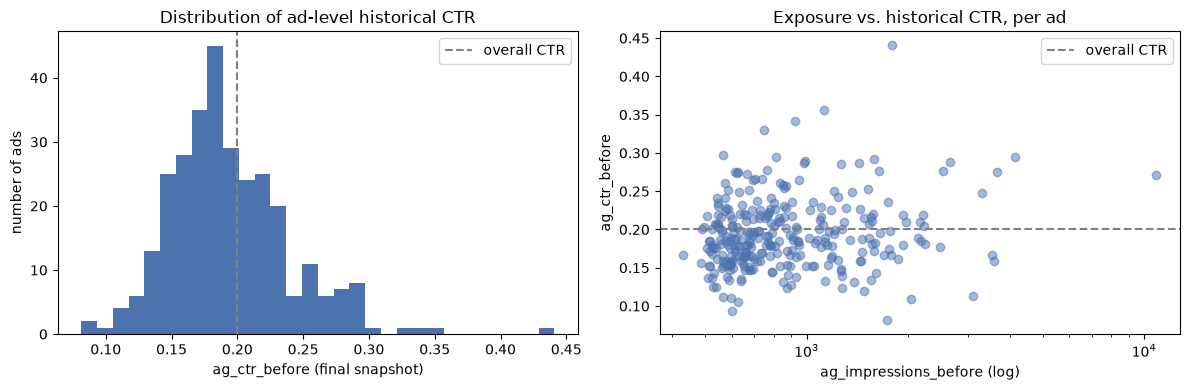

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ad_latest["ag_ctr_before"], bins=30, color="#4C72B0")
axes[0].axvline(df["click"].mean(), color="grey", linestyle="--", label="overall CTR")
axes[0].set_xlabel("ag_ctr_before (final snapshot)")
axes[0].set_ylabel("number of ads")
axes[0].set_title("Distribution of ad-level historical CTR")
axes[0].legend()

axes[1].scatter(ad_latest["ag_impressions_before"], ad_latest["ag_ctr_before"], alpha=0.5, color="#4C72B0")
axes[1].set_xscale("log")
axes[1].axhline(df["click"].mean(), color="grey", linestyle="--", label="overall CTR")
axes[1].set_xlabel("ag_impressions_before (log)")
axes[1].set_ylabel("ag_ctr_before")
axes[1].set_title("Exposure vs. historical CTR, per ad")
axes[1].legend()

plt.tight_layout()
plt.show()

**Trending ads** — `ag_ctr_trend_1d_vs_3d` is `ag_ctr_last_1d - ag_ctr_last_3d`: positive means the ad converted better in the last day than its trailing 3-day average (heating up), negative means the opposite (cooling down).

In [17]:
trend = ad_latest[["cate_id", "brand", "ag_impressions_last_3d", "ag_ctr_last_3d", "ag_ctr_last_1d", "ag_ctr_trend_1d_vs_3d"]]

print("Top 10 heating up:")
display(trend.sort_values("ag_ctr_trend_1d_vs_3d", ascending=False).head(10))

print("\nTop 10 cooling down:")
display(trend.sort_values("ag_ctr_trend_1d_vs_3d").head(10))

Top 10 heating up:


,cate_id,brand,ag_impressions_last_3d,ag_ctr_last_3d,ag_ctr_last_1d,ag_ctr_trend_1d_vs_3d
adgroup_id,,,,,,
744133,6261,270915,314.0,0.181529,0.272727,0.091199
715187,4520,283750,187.0,0.160428,0.250000,0.089572
646516,856,346405,168.0,0.101190,0.186441,0.085250
610242,6261,unknown,84.0,0.190476,0.250000,0.059524
709851,6261,unknown,299.0,0.153846,0.212121,0.058275
632086,1665,247789,329.0,0.200608,0.252101,0.051493
683061,1665,83836,316.0,0.132911,0.181818,0.048907
618945,6261,120040,178.0,0.168539,0.216667,0.048127
600745,6261,199779,186.0,0.215054,0.263158,0.048104



Top 10 cooling down:


,cate_id,brand,ag_impressions_last_3d,ag_ctr_last_3d,ag_ctr_last_1d,ag_ctr_trend_1d_vs_3d
adgroup_id,,,,,,
695844,6261,unknown,230.0,0.152174,0.000000,-0.152174
710060,4520,unknown,72.0,0.180556,0.066667,-0.113889
512448,4385,unknown,242.0,0.173554,0.066667,-0.106887
645506,6261,269352,169.0,0.130178,0.035714,-0.094463
577600,6426,162751,258.0,0.174419,0.083333,-0.091085
601687,4283,82527,491.0,0.187373,0.104478,-0.082895
703342,6426,454237,261.0,0.260536,0.179775,-0.080761
690501,4281,450736,230.0,0.191304,0.111111,-0.080193
626761,6519,unknown,289.0,0.214533,0.142857,-0.071676


**Volume leaders vs. revenue leaders** — are the most-shown ads also the ones generating the most (price-weighted) clicks, or are there high-value ads getting under-exposed?

In [18]:
top_volume = ad_latest.sort_values("ag_impressions_before", ascending=False).head(15)
top_revenue = ad_latest.sort_values("ag_revenue_before", ascending=False).head(15)

overlap = set(top_volume.index) & set(top_revenue.index)
print(f"Overlap between top-15 by volume and top-15 by revenue: {len(overlap)}/15 ads")

print("\nTop 15 by impressions:")
display(top_volume[["cate_id", "brand", "price", "ag_impressions_before", "ag_ctr_before", "ag_revenue_before"]])

print("\nTop 15 by revenue-before:")
display(top_revenue[["cate_id", "brand", "price", "ag_impressions_before", "ag_ctr_before", "ag_revenue_before"]])

Overlap between top-15 by volume and top-15 by revenue: 6/15 ads

Top 15 by impressions:


,cate_id,brand,price,ag_impressions_before,ag_ctr_before,ag_revenue_before
adgroup_id,,,,,,
710164,1665,unknown,109.0,10869,0.271782,321986.0
725105,4284,82527,118.0,4148,0.294359,144078.0
836889,6261,82527,176.0,3657,0.275362,177232.0
736349,1665,unknown,137.0,3590,0.158217,77816.0
747157,1665,unknown,122.5,3535,0.166054,71907.5
632644,4282,unknown,138.0,3319,0.247665,113436.0
659289,1665,unknown,162.0,3106,0.112685,56700.0
632432,6261,unknown,216.0,2660,0.287594,165240.0
711852,6261,unknown,119.0,2541,0.276269,83538.0



Top 15 by revenue-before:


,cate_id,brand,price,ag_impressions_before,ag_ctr_before,ag_revenue_before
adgroup_id,,,,,,
819177,4282,unknown,999.0,2230,0.204933,456543.0
710164,1665,unknown,109.0,10869,0.271782,321986.0
715171,6261,180031,509.0,2131,0.188644,204618.0
671481,1665,255820,599.0,1868,0.161135,180299.0
681970,1665,83836,588.0,1756,0.174260,179928.0
836889,6261,82527,176.0,3657,0.275362,177232.0
611303,4282,73218,499.0,1359,0.249448,169161.0
774050,6261,unknown,588.0,990,0.289899,168756.0
632432,6261,unknown,216.0,2660,0.287594,165240.0
